# Solphin Main Tutorial Notebook

At current this is only tested in inorganic semiconductor (non-perovskite) photovoltaic materials.

Calculating the \<name\> figure of merit requires various data characterising a material's optoelectronic properties. \<Placeholder\> provides methods to automate/assist calculating these properties using VASP (the Vienna Ab-initio Simulation Package).

In [14]:
#import the required modules

import solphin.db_fom as db_fom
import solphin.pv_fom as pv_fom
import solphin.db_plotting as db_plotting
import solphin.final_results as final_results
import solphin.vasp_inputs as vasp_inputs
import solphin.optics as optics
import solphin.spectral as spectral
import solphin.dos_plotting as dos_plotting
from pymatgen.io.vasp import Vasprun
import numpy as np # version - 1.26.4
from matplotlib import pyplot as plt

%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Using Solphin to generate VASP input files

### Geometry Optimisation / Relaxation

The initial step of any DFT structural property study is a geometry optimisation to find the lowest energy position of the atoms in your system. For this you need:

- A starting structure, this can be obtained from the ICSD, the Materials Project, or experimental studies. Placeholder currently accepts  the VASP POSCAR/CONTCAR, .cif, .xyz, or .json formats.

- Appropiate values for the `ENCUT` and `KSPACING` for your system. Convergence testing is the commonly used method of determining the appropiate values, see [here](https://github.com/kavanase/vaspup2.0).

- To choose a functional. It is recommended to use hybrid DFT (HSE06 or PBE0) to achieve publishable results.

In [2]:
# Set the structure filename and calculation settings

filename = 'cdte/relaxed_primitive_POSCAR'
relax_directory = 'relax'                    # The folder you want to run the calculation in
functional = 'HSE06'                         # The DFT functional
encut = 450                                  # Plane-wave energy cutoff                
kspacing = 0.2                               # k-point sampling density


# Load the structure
structure = vasp_inputs.read_structure_pmg(filename)

In [ ]:
# Generate the calculations
vasp_inputs.write_vasp_calculation(structure=structure, recipe=functional, out_dir=relax_directory, patches=['relax_cell', 'tight_relax'], user_incar_settings={"KSPACING": kspacing, "ENCUT": encut})

### Electronic Density of States and Optical Absorption

* This calculation produces the optoelectronic data we need.

* This time the structure we feed in is the `CONTCAR` generated in the previous step, which contains our "relaxed" or "optimised" structure.

* To get the most accurate results, the shape of the Density of States and optical absorption spectrum should be sufficiently converged with respect to `KSPACING` and `NBANDS`.

In [2]:
#Set the input structure (the output of the previous step) and the output directory for the current step
# contcar = f'{relax_directory}/CONTCAR'
optics_directory = 'optics'

In [ ]:
# Load the structure
structure = vasp_inputs.read_structure_pmg("relax/CONTCAR")

# Generate the calculation
vasp_inputs.write_vasp_calculation(
    structure=structure, 
    recipe=functional, 
    out_dir=optics_directory, 
    patches=["optics"], 
    user_incar_settings={"KSPACING": kspacing, "ENCUT": encut, "ISPIN": 1, "ISMEAR": -5, "SIGMA": 0.02, "LORBIT": 14})

#### Analysing the Results

##### Electronic Density of States

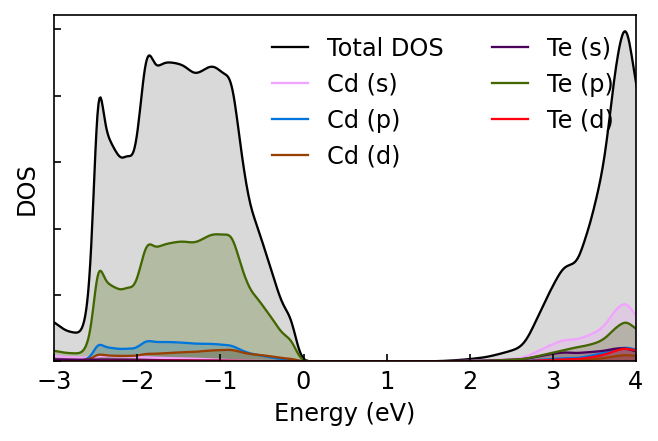

In [13]:
dos_plotting.plot_dos(filename=f'{optics_directory}/vasprun.xml', xmin=-3, xmax=4, gaussian=0.05, save=False)

##### Optical Absorption Spectrum

In [21]:
optics_directory = 'cc'

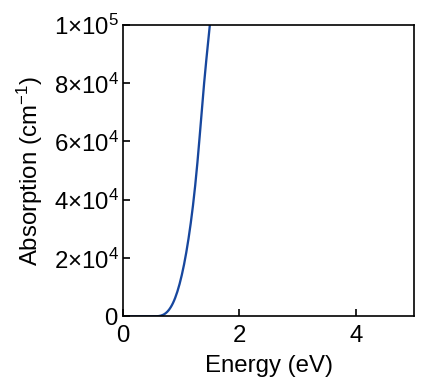

In [22]:
optics.plot_absorption(optics_directory, xmax=5)

## Calculating the SLME and Blank et al. metrics

In [23]:
spectrum_type = "AM1.5" # One of "AM1.5", "Fluorescent", "Blue LED", "Green LED", "Red LED", "White LED", "IR LED", "Photopic"
spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)

direct = 0.6# Direct Bandgap of your material from the band_std
indir= 0.6 # Indirect Bandgap of your material from the band_std (if none given use the direct bandgap twice)

In [24]:
# Generates a n_real.dat for use in SLME and Blank et al

optics.generate_n_real(optics_directory)

In [25]:
#Get energy and absorption form absorption.dat. Get from sumo-optplot

spectral_average, spectral_dispersion = spectral.generate_spectral_parameters(optics_directory, spectrum, E_gap=direct)
print(spectral_average, spectral_dispersion)

217025.02932910933 0.8367395793665982


### SLME

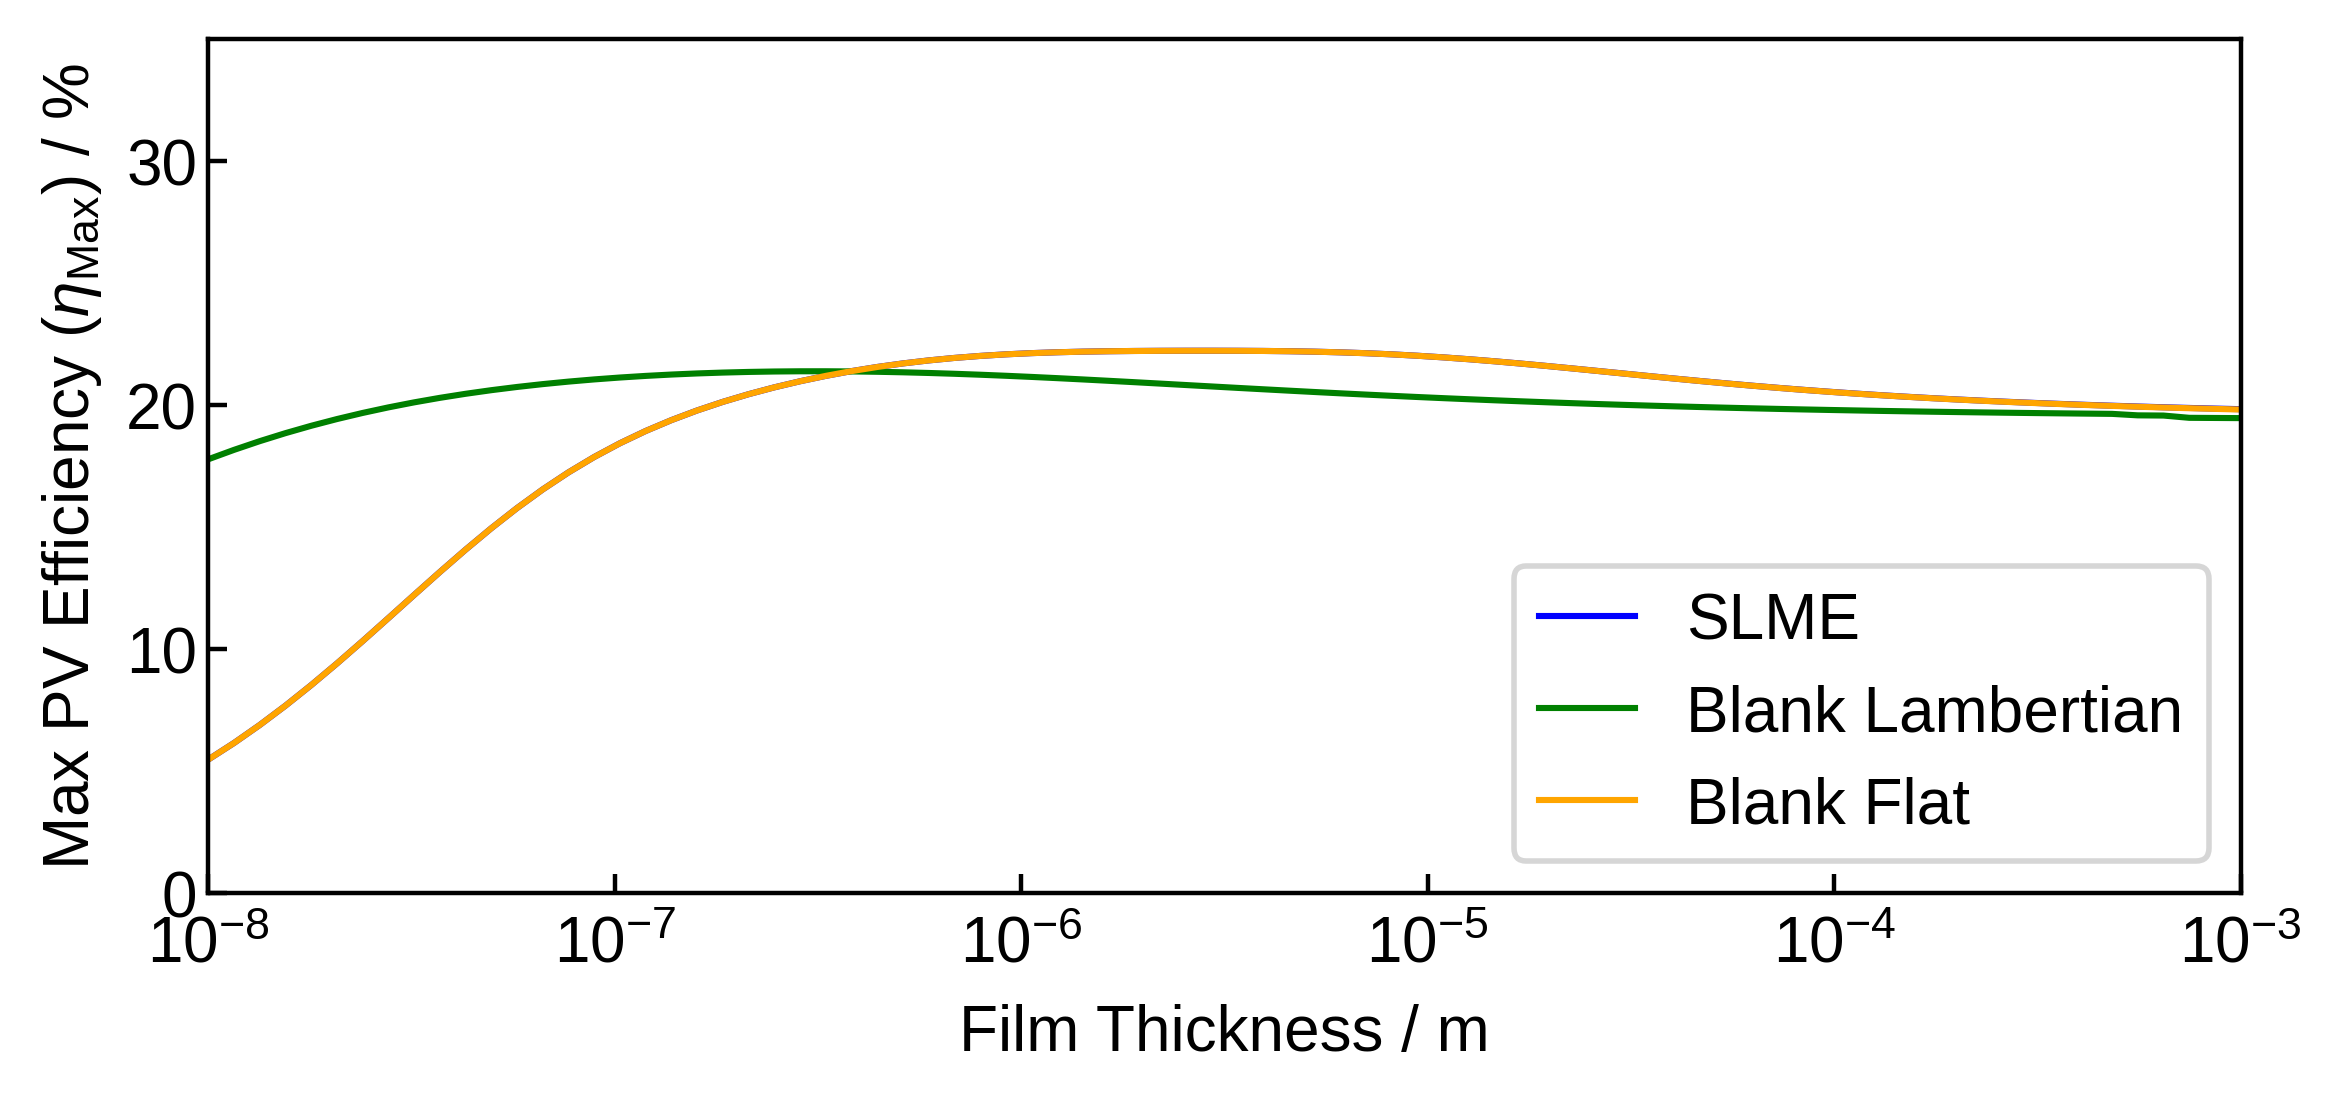

In [26]:
optics.make_blank_plot(optics_directory, direct_gap=direct, indirect_gap=indir,spectrum_type="AM1.5", Qi=1.0, n=3.5, thickness_range=None)
    

## Obtaining the Detailed Balance and Shockley-Queisser Limit

By supplying a band gap (eV) and operating temperature (K), the Detailed Balance results can be obtained and plotted.

In [10]:
# Define the operating temperature of the cell and Fundamental band gap (?)

Tcell = 300             # Operating Temperature
Egap = 1.45             # Using CdTe value
spectrum_type = "AM1.5" # One of "AM1.5", "Fluorescent", "Blue LED", "Green LED", "Red LED", "White LED", "IR LED", "Photopic"

# Convert the spectrum

spectrum = db_fom.load_spectrum(spectrum_type=spectrum_type)
photon_spectrum = db_fom.convert_spectrum(spectrum)

This can also be done interactively:

In [11]:
%matplotlib widget
db_plotting.plot_db_combined_interactive()

RuntimeError: 'widget' is not a recognised GUI loop or backend name

## Calculating the \<name\> Figure of Merit

In [5]:
E_gap = 1.45

Tcell = 300

fom = final_results.Crovetto_efficiency(E_gap, photon_spectrum, alpha_cm, tau, sigma, dos_mass, dop_density, epsilon, mu, Tcell)

NameError: name 'alpha_cm' is not defined